# Inference over a path in physical time

This notebook follows a latent trajectory as observations arrive on an irregular time grid.
We first check a linear-Gaussian model, then learn its unknown diffusion scale using a
population of Kalman filters and a population of particle filters (SMC²). Finally we
use a nonlinear observation model and rejuvenate a trajectory with particle Gibbs.

Install the project with its `notebooks` extra. All inference below uses the functional,
JIT-compatible APIs. The initial law is at `t0`; each entry in `ts` is a **later** observation
time. A mask marks missing observations. The latent paths include the initial state.

The implementations reuse probjax's filter kernels and particle backward simulator,
and BlackJAX's resampling, ESS, and Metropolis acceptance utilities.

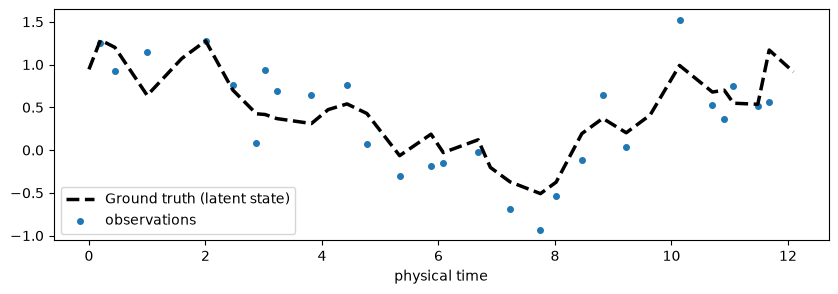

In [1]:
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax.scipy.stats import norm
from probjax.inference import (
    kalman_backend, particle_backend, run_temporal_filter,
    temporal_smc, run_temporal_smc, ReplayData,
    sample_gaussian_paths, smooth_gaussian_path,
    sample_particle_paths, particle_gibbs, sample_joint_paths,
    population_diagnostics, init_streaming_window, append_streaming_window,
    streaming_window_trace,
)

key = jax.random.key(2026)
def next_key():
    global key
    key, result = jax.random.split(key)
    return result

t0 = jnp.array(0.0)
num_steps = 32
ts = jnp.cumsum(jax.random.uniform(next_key(), (num_steps,), minval=0.15, maxval=0.6))
times = jnp.concatenate((t0[None], ts))
true_theta = jnp.log(0.3)  # log diffusion variance per unit time
observation_sd = 0.35
observed = jnp.arange(num_steps) % 7 != 3

def simulate(observation_fn):
    x0 = jax.random.normal(next_key(), (1,))
    noise = jax.random.normal(next_key(), (num_steps, 1))
    x = x0 + jnp.cumsum(jnp.sqrt(jnp.exp(true_theta) * jnp.diff(times))[:, None] * noise, axis=0)
    y = observation_fn(x) + observation_sd * jax.random.normal(next_key(), x.shape)
    return jnp.concatenate((x0[None], x)), y

truth, ys = simulate(lambda x: x)
plt.figure(figsize=(10, 3))
plt.plot(times, truth[:, 0], color='black', linestyle='--', linewidth=2.5, zorder=5, label='Ground truth (latent state)')
plt.scatter(ts[observed], ys[observed, 0], s=16, label='observations')
plt.xlabel('physical time'); plt.legend(); plt.show()

## Known parameter: filtering and joint trajectory sampling

The process is a random walk with transition variance proportional to elapsed time.
Kalman filtering is exact here. Backward Gaussian sampling preserves dependence between
times; drawing independently from the smoothed marginal distributions would not.
We also compare the accumulated predictive likelihood with the joint observation density.

The right-hand panel compares terminal trajectory samples with the **exact final-state posterior** $p(x_T \mid y)$, computed independently by conditioning the joint Gaussian distribution. This is a posterior distribution, distinct from the simulated latent path.

Incremental / joint log likelihood: -20.320669174194336 -20.320669174194336


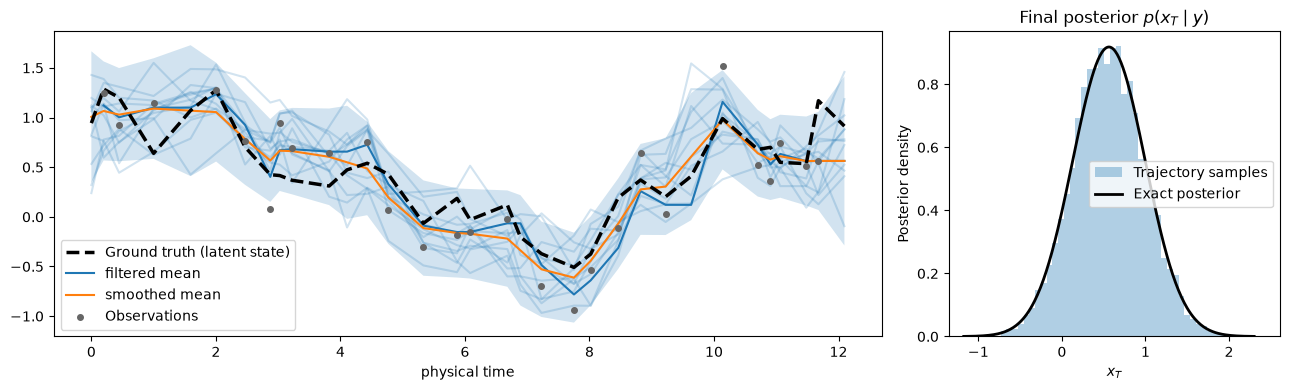

In [2]:
def transition_model(theta, previous, current):
    return jnp.eye(1), jnp.eye(1) * jnp.exp(theta) * (current - previous)

kf = kalman_backend(
    lambda theta, t: (jnp.zeros(1), jnp.eye(1)),
    transition_model,
    lambda theta, t: (jnp.eye(1), jnp.eye(1) * observation_sd**2),
)
initial = kf.init(next_key(), true_theta, t0)
filter_key = next_key()
run_kf = jax.jit(lambda k, state: run_temporal_filter(
    kf, k, state, true_theta, ts, ys, observed=observed, history='full'
))
filtered = run_kf(filter_key, initial)
means, covariances = smooth_gaussian_path(filtered.trace, lambda a, b: jnp.eye(1))
paths = sample_gaussian_paths(next_key(), filtered.trace, lambda a, b: jnp.eye(1), num_samples=10000)

idx = np.flatnonzero(np.asarray(observed))
obs_cov = 1.0 + jnp.exp(true_theta) * jnp.minimum(ts[idx, None], ts[None, idx])
obs_cov += observation_sd**2 * jnp.eye(len(idx))
exact_logz = jax.scipy.stats.multivariate_normal.logpdf(ys[idx, 0], jnp.zeros(len(idx)), obs_cov)
np.testing.assert_allclose(filtered.log_likelihood, exact_logz, atol=2e-4)
print('Incremental / joint log likelihood:', float(filtered.log_likelihood), float(exact_logz))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [2.5, 1]})
plt.sca(axes[0])
plt.plot(times, paths[:, :12, 0], color='C0', alpha=0.2)
plt.plot(times, truth[:, 0], color='black', linestyle='--', linewidth=2.5, zorder=5, label='Ground truth (latent state)')
plt.plot(ts, filtered.trace.states.mean[:, 0], label='filtered mean')
plt.plot(times, means[:, 0], label='smoothed mean')
std = jnp.sqrt(covariances[:, 0, 0])
plt.fill_between(times, means[:, 0]-1.96*std, means[:, 0]+1.96*std, alpha=0.2)
plt.scatter(ts[observed], ys[observed, 0], s=16, color='0.4', zorder=6, label='Observations')
plt.xlabel('physical time'); plt.legend()

# Independently condition the joint Gaussian law to obtain p(x_T | y_observed).
final_cross_cov = 1.0 + jnp.exp(true_theta) * ts[idx]
exact_final_mean = final_cross_cov @ jnp.linalg.solve(obs_cov, ys[idx, 0])
exact_final_var = (1.0 + jnp.exp(true_theta) * ts[-1]
                   - final_cross_cov @ jnp.linalg.solve(obs_cov, final_cross_cov))
np.testing.assert_allclose(filtered.state.mean[0], exact_final_mean, atol=2e-5)
np.testing.assert_allclose(filtered.state.cov[0, 0], exact_final_var, atol=2e-5)
x_grid = jnp.linspace(exact_final_mean - 4*jnp.sqrt(exact_final_var),
                      exact_final_mean + 4*jnp.sqrt(exact_final_var), 300)
axes[1].hist(np.asarray(paths[-1, :, 0]), bins=50, density=True, alpha=0.35,
             label='Trajectory samples')
axes[1].plot(x_grid, norm.pdf(x_grid, exact_final_mean, jnp.sqrt(exact_final_var)),
             color='black', linewidth=2, label='Exact posterior')
axes[1].set(xlabel=r'$x_T$', ylabel='Posterior density', title=r'Final posterior $p(x_T \mid y)$')
axes[1].legend()
plt.tight_layout(); plt.show()

## Streaming, bounded history, and compilation cost

A single compiled step processes only the new interval. The batch runner uses the same
key-splitting convention. `history='none'` retains just the current state;
`history=8` uses a ring buffer for the latest eight intervals. Sampling a windowed trace
returns paths only inside that window, conditional on the filtering distribution at its start.
Compilation is timed separately from warm execution.

In [3]:
step = jax.jit(kf.step)
stream_key, state, logz = filter_key, initial, 0.0
for t, y, present in zip(ts, ys, observed):
    stream_key, step_key = jax.random.split(stream_key)
    state, info = step(step_key, state, true_theta, t, y, present)
    logz = logz + info.log_likelihood
np.testing.assert_allclose(state.mean, filtered.state.mean, atol=1e-6)
np.testing.assert_allclose(logz, filtered.log_likelihood, atol=1e-5)

window = run_temporal_filter(kf, next_key(), initial, true_theta, ts, ys, observed=observed, history=8)
assert window.trace.states.mean.shape[0] == 8

compiled_run = jax.jit(lambda k, state: run_temporal_filter(
    kf, k, state, true_theta, ts, ys, observed=observed, history='none'
))
start = time.perf_counter()
executable = compiled_run.lower(filter_key, initial).compile()
compile_seconds = time.perf_counter() - start
executable(filter_key, initial).log_likelihood.block_until_ready()
start = time.perf_counter()
for _ in range(20):
    executable(filter_key, initial).log_likelihood.block_until_ready()
print(f'Compile: {compile_seconds:.3f}s; warm run: {(time.perf_counter()-start)/20*1e3:.3f}ms')

Compile: 0.064s; warm run: 0.027ms


## Parameter SMC: a population of filters

Each outer particle contains a log diffusion variance and its own filter state.
An observation updates its weight using the filter's predictive likelihood increment.
Low outer ESS triggers joint resampling and parameter rejuvenation.

A parameter proposal reruns the observed prefix. This cost grows with elapsed time,
but ordinary propagation does not replay history. With particle likelihood estimates,
a rejected proposal retains the **current estimate and filter state**. This is the
pseudo-marginal construction, not an average of noisy log likelihoods.

The Kalman backend integrates out the trajectory exactly. SMC² replaces this likelihood
with the particle filter's unbiased likelihood estimate. Both posterior populations are
Monte Carlo approximations. Here the same prior draws make the two backends easy to compare.

The final parameter histogram is overlaid with a **reference posterior** obtained from exact Kalman likelihoods on a dense grid and numerical normalization. The reference is exact in its likelihood, with finite-grid quadrature error. Both histograms use probability density, and the reference includes the change-of-variable Jacobian from log variance to variance.

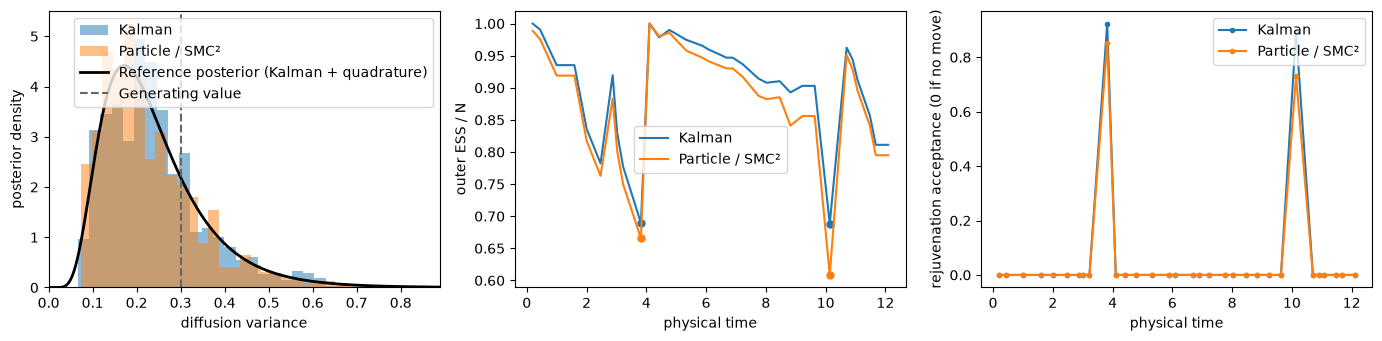

In [4]:
n_parameters, n_latent = 512, 256
prior_mean, prior_sd = jnp.log(0.3), 0.8
parameter_particles = prior_mean + prior_sd * jax.random.normal(next_key(), (n_parameters,))
logprior = lambda theta: norm.logpdf(theta, prior_mean, prior_sd)
proposal = lambda k, theta: (theta + 0.2 * jax.random.normal(k), 0.0)

def initial_particles(k, theta, t):
    return jax.random.normal(k, (n_latent, 1))

def particle_transition(k, theta, particles, previous, current):
    return particles + jnp.sqrt(jnp.exp(theta)*(current-previous)) * jax.random.normal(k, particles.shape)

def linear_likelihood(theta, particles, y, t):
    return norm.logpdf(y, particles, observation_sd).sum(-1)

pf = particle_backend(initial_particles, particle_transition, linear_likelihood)
kalman_smc = temporal_smc(kf, logprior, proposal_fn=proposal, ess_threshold=0.7)
particle_smc = temporal_smc(pf, logprior, proposal_fn=proposal, ess_threshold=0.7)

def infer(kernel):
    state = kernel.init(next_key(), parameter_particles, t0)
    run = jax.jit(lambda k, state: run_temporal_smc(
        kernel, k, state, ts, ys, observed=observed, history='full'
    ))
    return run(next_key(), state)

kalman_result, particle_result = infer(kalman_smc), infer(particle_smc)
assert bool(kalman_result.trace.infos.valid.all())
assert bool(particle_result.trace.infos.valid.all())

# Exact marginal likelihood from Kalman filtering, normalized by 1D quadrature.
# The prior is on theta=log(q), so density in q includes the 1/q Jacobian.
theta_grid = jnp.linspace(prior_mean - 6*prior_sd, prior_mean + 6*prior_sd, 512)
def reference_logposterior(theta):
    state = kf.init(jax.random.key(0), theta, t0)  # Kalman backend is deterministic.
    result = run_temporal_filter(kf, jax.random.key(0), state, theta, ts, ys,
                                 observed=observed, history='none')
    return logprior(theta) + result.log_likelihood
reference_logp = jax.jit(jax.vmap(reference_logposterior))(theta_grid)
reference_scaled = jnp.exp(reference_logp - reference_logp.max())
reference_theta_density = reference_scaled / jnp.trapezoid(reference_scaled, theta_grid)
q_grid = jnp.exp(theta_grid)
reference_q_density = reference_theta_density / q_grid
np.testing.assert_allclose(jnp.trapezoid(reference_q_density, q_grid), 1.0, atol=1e-4)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for label, result in [('Kalman', kalman_result), ('Particle / SMC²', particle_result)]:
    theta = jnp.exp(result.state.parameters)
    weights = jnp.exp(result.state.log_weights)
    axes[0].hist(np.asarray(theta), weights=np.asarray(weights), bins=35, density=True, alpha=0.5, label=label)
    axes[1].plot(ts, result.trace.infos.ess / n_parameters, label=label)
    events = np.asarray(result.trace.infos.resampled)
    axes[1].scatter(np.asarray(ts)[events], np.asarray(result.trace.infos.ess/n_parameters)[events], s=25)
    axes[2].plot(ts, result.trace.infos.acceptance_rate, '.-', label=label)
axes[0].plot(q_grid, reference_q_density, color='black', linewidth=2,
             label='Reference posterior (Kalman + quadrature)')
reference_cdf = jnp.cumsum((reference_theta_density[1:] + reference_theta_density[:-1])
                          * jnp.diff(theta_grid) / 2)
upper_q = jnp.exp(jnp.interp(0.999, reference_cdf, theta_grid[1:]))
axes[0].set_xlim(0, float(upper_q))
axes[0].axvline(float(jnp.exp(true_theta)), color='0.4', linestyle='--', label='Generating value')
axes[0].set(xlabel='diffusion variance', ylabel='posterior density')
axes[1].set(xlabel='physical time', ylabel='outer ESS / N')
axes[2].set(xlabel='physical time', ylabel='rejuvenation acceptance (0 if no move)')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## Joint parameter–trajectory draws and resuming a stream

For the linear-Gaussian model, sample a parameter from the outer posterior and then sample
its conditional Gaussian trajectory. This integrates parameter uncertainty into path bands.
When resuming parameter SMC, rejuvenation needs `ReplayData` beginning at the original `t0`;
supplying only the latest chunk is not sufficient. Unused future observations in the replay
arrays are never assimilated early.

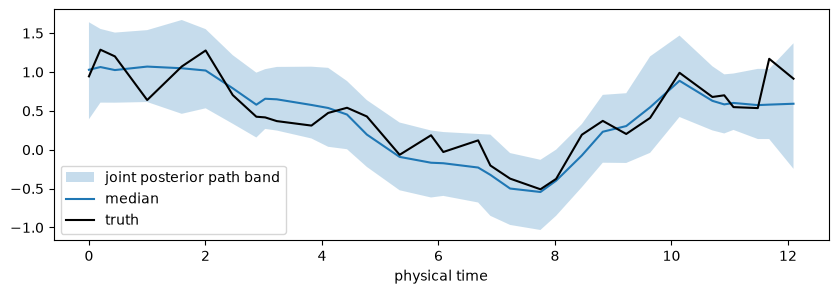

In [5]:
joint_draws = jax.jit(lambda k: sample_joint_paths(
    k, kalman_result.state, kf, ReplayData(ts, ys, observed),
    num_samples=1000, transition_fn=lambda theta, a, b: jnp.eye(1), batch_size=64,
))(next_key())
assert bool(joint_draws.valid)
joint_paths = joint_draws.paths[:, :, 0]
lo, median, hi = jnp.quantile(joint_paths, jnp.array([0.025, 0.5, 0.975]), axis=0)
plt.figure(figsize=(10, 3))
plt.fill_between(times, lo, hi, alpha=0.25, label='joint posterior path band')
plt.plot(times, median, label='median'); plt.plot(times, truth[:, 0], 'k', label='truth')
plt.xlabel('physical time'); plt.legend(); plt.show()

replay = ReplayData(ts, ys, observed)
initial_outer = kalman_smc.init(next_key(), parameter_particles, t0)
stream_key = next_key()
first = run_temporal_smc(kalman_smc, stream_key, initial_outer, ts[:16], ys[:16], observed=observed[:16], replay=replay)
second = run_temporal_smc(kalman_smc, first.key, first.state, ts[16:], ys[16:], observed=observed[16:], replay=replay)
batch = run_temporal_smc(kalman_smc, stream_key, initial_outer, ts, ys, observed=observed)
np.testing.assert_allclose(second.state.log_weights, batch.state.log_weights, atol=1e-5)
np.testing.assert_allclose(second.state.parameters, batch.state.parameters, atol=1e-5)

## Nonlinear observations and trajectory rejuvenation

Now observe `x + 0.15*x**2` with Gaussian noise. The particle backend handles this without
linearizing the likelihood. We run SMC² for the diffusion parameter, then illustrate
trajectory inference conditional on a representative posterior parameter.

Backward simulation reduces reliance on stored genealogies. Particle Gibbs with ancestor
sampling (PGAS) further supplies an MCMC transition preserving the conditional smoothing
target. Successive PGAS draws are correlated; this short demonstration is not a convergence
claim. Unlike the linear example, conditional trajectory inference is Monte Carlo.

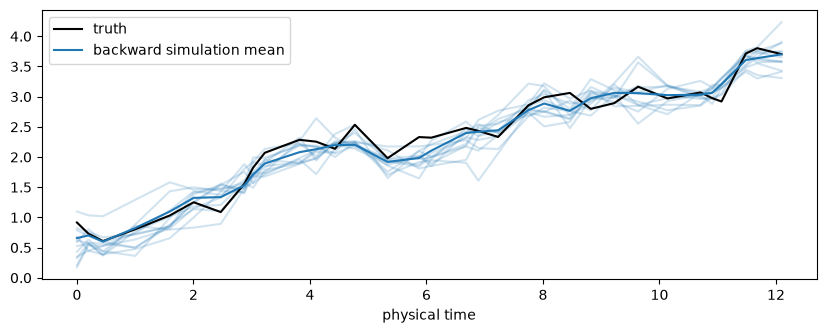

Nonlinear outer ESS: 455.8658447265625


In [6]:
nonlinear_truth, nonlinear_ys = simulate(lambda x: x + 0.15*x**2)
def nonlinear_likelihood(theta, particles, y, t):
    return norm.logpdf(y, particles + 0.15*particles**2, observation_sd).sum(-1)

nonlinear_pf = particle_backend(initial_particles, particle_transition, nonlinear_likelihood)
nonlinear_smc = temporal_smc(nonlinear_pf, logprior, proposal_fn=proposal, ess_threshold=0.7)
nonlinear_initial = nonlinear_smc.init(next_key(), parameter_particles, t0)
nonlinear_result = jax.jit(lambda k, state: run_temporal_smc(
    nonlinear_smc, k, state, ts, nonlinear_ys, observed=observed, history='full'
))(next_key(), nonlinear_initial)
assert bool(nonlinear_result.trace.infos.valid.all())
theta = jnp.sum(nonlinear_result.state.parameters * jnp.exp(nonlinear_result.state.log_weights))
conditional = run_temporal_filter(
    nonlinear_pf, next_key(), nonlinear_pf.init(next_key(), theta, t0),
    theta, ts, nonlinear_ys, observed=observed,
)
def transition_logdensity(theta, new, old, previous, current):
    return norm.logpdf(new, old, jnp.sqrt(jnp.exp(theta)*(current-previous))).sum(-1)
paths = sample_particle_paths(
    next_key(), conditional.trace, num_samples=80,
    transition_logdensity_fn=lambda new, old, a, b: transition_logdensity(theta, new, old, a, b),
)
reference = paths[:, 0]

def pgas_step(carry, _):
    k, path = carry
    k, step_key = jax.random.split(k)
    path = particle_gibbs(
        step_key, path, theta, t0, ts, nonlinear_ys,
        initial_fn=initial_particles, transition_fn=particle_transition,
        transition_logdensity_fn=transition_logdensity,
        log_likelihood_fn=nonlinear_likelihood, num_particles=n_latent, observed=observed,
    )
    return (k, path), path

_, pgas_paths = jax.jit(lambda k, path: jax.lax.scan(pgas_step, (k, path), None, length=40))(next_key(), reference)
plt.figure(figsize=(10, 3.5))
plt.plot(times, pgas_paths[-12:, :, 0].T, alpha=0.2, color='C0')
plt.plot(times, nonlinear_truth[:, 0], color='black', label='truth')
plt.plot(times, paths[:, :, 0].mean(1), label='backward simulation mean')
plt.xlabel('physical time'); plt.legend(); plt.show()
print('Nonlinear outer ESS:', float(nonlinear_result.trace.infos.ess[-1]))

## Adaptive controls and history across streaming chunks

Observation tempering uses conditional ESS to avoid assimilating a difficult observation in
one jump. The Gaussian proposal adapts its covariance and scale; the number of moves adapts
within an explicit cap. For particle likelihoods the bridge is defined on the retained
auxiliary filter estimates, with valid pseudo-marginal moves.

The persistent window below spans two streaming calls. Its carry stays fixed in shape.
Weight ESS and ancestral diversity describe different properties; resampling restores
uniform weights without restoring lost ancestors.

In [7]:
advanced_kernel = temporal_smc(
    kf, logprior, adaptive_proposal=True, adaptive_num_steps=True,
    max_rejuvenation_steps=8, tempering_ess=0.9, batch_size=32,
)
advanced_initial = advanced_kernel.init(next_key(), parameter_particles[:64], t0)
advanced = jax.jit(lambda k, state: run_temporal_smc(
    advanced_kernel, k, state, ts, ys, observed=observed, history='full',
))(next_key(), advanced_initial)
assert bool(advanced.trace.infos.valid.all())
diagnostics = population_diagnostics(
    advanced.state.parameters, advanced.state.log_weights, advanced.state.lineages,
)
print('Final ESS / distinct particles / surviving initial ancestors:',
      float(diagnostics.ess), int(diagnostics.unique_particles), int(diagnostics.unique_ancestors))
print('Maximum observation bridge stages:', int(advanced.trace.infos.num_tempering_steps.max()))
print('Next rejuvenation move budget:', int(advanced.state.move_steps))

stream_initial = kf.init(next_key(), true_theta, t0)
info_shape = jax.eval_shape(kf.step, next_key(), stream_initial, true_theta, ts[0], ys[0], observed[0])[1]
window = init_streaming_window(stream_initial, info_shape, capacity=8)

@jax.jit
def stream_chunk(carry, times, observations, mask):
    def step(carry, data):
        key, state, window = carry
        key, step_key = jax.random.split(key)
        t, y, present = data
        state, info = kf.step(step_key, state, true_theta, t, y, present)
        window = append_streaming_window(window, state, info)
        return (key, state, window), None
    return jax.lax.scan(step, carry, (times, observations, mask))[0]

carry = stream_chunk((next_key(), stream_initial, window), ts[:16], ys[:16], observed[:16])
carry = stream_chunk(carry, ts[16:], ys[16:], observed[16:])
window_trace, valid = streaming_window_trace(carry[2])
assert bool(valid.all())
np.testing.assert_allclose(window_trace.ts, ts[-8:])
print('Window retained the final eight intervals across both chunks.')


Final ESS / distinct particles / surviving initial ancestors: 62.37760925292969 64 43
Maximum observation bridge stages: 2
Next rejuvenation move budget: 8
Window retained the final eight intervals across both chunks.


## Costs and boundaries

- Ordinary filtering updates process one new interval, with fixed carry shapes.
- Full latent history uses O(T Nₓ D) storage; a fixed window uses O(L Nₓ D).
  Outer SMC state uses O(Nθ Nₓ D) with a particle backend, excluding covariance/model costs.
  Saving the whole outer history multiplies that storage by T.
- FFBSi costs O(T Nₓ M) for M paths. Ancestry reconstruction is O(T M), but old paths can collapse.
- Parameter rejuvenation replays the prefix and grows with elapsed time. Fixed particle counts
  avoid recompilation. Observation tempering is available through `tempering_ess`;
  `adapt_particle_count` selects explicit compiled capacity buckets on the host.
- Inputs use a discrete, increasing physical-time grid. Continuous dynamics must supply an
  interval transition (exact or discretized). Kalman integration is exact only for linear-Gaussian
  models; approximate filters must not be labeled exact/unbiased for SMC².
- Numerical failure is reported by outer `info.valid`; inspect it in compiled runs.

References: [SMC²](https://arxiv.org/abs/1101.1528),
[Particle Gibbs with ancestor sampling](https://www.jmlr.org/beta/papers/v15/lindsten14a.html).